In [1]:
!pip install wfdb

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!python -m pip install heartpy

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install -Uqq ipdb

In [4]:
path = r"C:\Users\Niños\Downloads\BD2-20260218T192722Z-1-001/BD2"
import os
print(os.listdir(path))

['100.atr', '100.dat', '100.hea', '100.xws', '101.atr', '101.dat', '101.hea', '101.xws', '102-0.atr', '102.atr', '102.dat', '102.hea', '102.xws', '103.atr', '103.dat', '103.hea', '103.xws', '104.atr', '104.dat', '104.hea', '104.xws', '105.atr', '105.dat', '105.hea', '105.xws', '106.atr', '106.dat', '106.hea', '106.xws', '107.atr', '107.dat', '107.hea', '107.xws', '108(1).atr', '108(1).at_', '108(1).hea', '108(1).xws', '108.atr', '108.at_', '108.dat', '108.hea', '108.xws', '109(1).atr', '109(1).hea', '109(1).xws', '109.atr', '109.dat', '109.hea', '109.xws', '110(1).atr', '110(1).hea', '110(1).xws', '110.atr', '110.dat', '110.hea', '110.xws', '111.atr', '111.dat', '111.hea', '111.xws', '112.atr', '112.dat', '112.hea', '112.xws', '113.atr', '113.dat', '113.hea', '113.xws', '114.atr', '114.dat', '114.hea', '114.xws', '115.atr', '115.dat', '115.hea', '115.xws', '116.atr', '116.dat', '116.hea', '116.xws', '117.atr', '117.at_', '117.dat', '117.hea', '117.xws', '118.atr', '118.dat', '118.hea',

In [5]:
!pip install -q heartpy wfdb scikit-learn scipy matplotlib


In [6]:
!pip install setuptools==68.2.2


Defaulting to user installation because normal site-packages is not writeable


In [7]:
!pip install heartpy==1.2.7

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import wfdb
from sklearn import preprocessing
from wfdb import processing
import heartpy as hp
import statistics as stats
import pdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, medfilt

In [9]:
# Funcion para llamar los registros
def caller(register):
    registros = sorted([
        f.replace(".hea", "")
        for f in os.listdir(path)
        if f.endswith(".hea")
    ])

    rg = registros[register]

    print("Índice:", register, "Registro:", rg)
    print("Ruta correcta:", os.path.join(path, rg))

    record = wfdb.rdrecord(os.path.join(path, rg))
    annotation = wfdb.rdann(os.path.join(path, rg), 'atr')

    return record, annotation
# Normalizer
def normalizer(signal):
    data_normal=preprocessing.normalize(signal, norm='l2')
    return data_normal

def normalizermm(signal):
    data_normal=preprocessing.minmax_scale(signal, feature_range=(0, 1), axis=0)
    return data_normal

# QRS detector
def qrs_detect(signal,fs):
  xqrs = processing.XQRS(sig=signal, fs=fs)
  xqrs.detect()
  qrs_indices = xqrs.qrs_inds
  return qrs_indices
# SEGMENTATION
def segment(signal,qrs_indices,fs):
  pre = int(0.2 * fs)   # 200 ms before R
  post = int(0.4 * fs)  # 400 ms after R
  segments = []
  for idx in qrs_indices:
      start = max(idx - pre, 0)
      end = min(idx + post, len(signal))
      segment = signal[start:end]
      segments.append(segment)
  segments = [seg for seg in segments if len(seg) == pre + post]
  return np.array(segments)

#filters
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# BandPass filter
def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

# Notch filter
def apply_notch_filter(data, freq, fs, Q=30):
    b, a = iirnotch(w0=freq/(fs/2), Q=Q)
    return filtfilt(b, a, data)

# Median filter
def apply_median_filter(data, kernel_size=5):
    return medfilt(data, kernel_size=kernel_size)

# Moving average filter (simple)
def apply_moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

def filter_data(segments, fs, lowcut, highcut, notch_freq, Q,ismedian=False,ismoving=False):
  filtered_segments = []
  for segment in segments:
      seg_filter = apply_bandpass_filter(segment, lowcut, highcut, fs)
      seg_filter = apply_notch_filter(seg_filter, notch_freq, fs, Q)
      if(ismedian):
        seg_filter = apply_median_filter(seg_filter, kernel_size=5)
      if(ismoving):
        seg_filter = apply_moving_average(seg_filter, window_size=5)
      filtered_segments.append(seg_filter)
  filtered_segments = np.array(filtered_segments)
  return filtered_segments
# binarizer
def binarizer(annotation):

  symbols = np.array(annotation.symbol)
  sample=np.array(annotation.sample)

  special_symbols = ['+', '/', '!', '[', ']', 'x', '(', ')', '|']

  # Filter special_symbols
  mask = ~np.isin(symbols, special_symbols)

  # Only beat anotations
  symbols_filtered = symbols[mask]

  # Array 0 = no arrhythmia (N), 1 =  arrhythmia (oters)
  is_arritmia = np.where(symbols_filtered == 'N', 0, 1)

  return sample[is_arritmia],is_arritmia

# complete signals
def complete(signal,signal2,target):
  len_signal=len(signal)
  len_signal2=len(signal2)
  len_target=len(target)
  min_len=min(len_signal,len_signal2,len_target)
  signal=signal[0:min_len]
  signal2=signal2[0:min_len]
  target=target[0:min_len]
  return signal,signal2,target

In [10]:
register,annotation=caller(0)

Índice: 0 Registro: 100
Ruta correcta: C:\Users\Niños\Downloads\BD2-20260218T192722Z-1-001/BD2\100


In [11]:
register.__dict__

{'record_name': '100',
 'n_sig': 2,
 'fs': 360,
 'counter_freq': None,
 'base_counter': None,
 'sig_len': 650000,
 'base_time': None,
 'base_date': None,
 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'],
 'sig_name': ['MLII', 'V5'],
 'p_signal': array([[-0.145, -0.065],
        [-0.145, -0.065],
        [-0.145, -0.065],
        ...,
        [-0.675, -0.365],
        [-0.765, -0.335],
        [-1.28 ,  0.   ]], shape=(650000, 2)),
 'd_signal': None,
 'e_p_signal': None,
 'e_d_signal': None,
 'file_name': ['100.dat', '100.dat'],
 'fmt': ['212', '212'],
 'samps_per_frame': [1, 1],
 'skew': [None, None],
 'byte_offset': [None, None],
 'adc_gain': [200.0, 200.0],
 'baseline': [1024, 1024],
 'units': ['mV', 'mV'],
 'adc_res': [11, 11],
 'adc_zero': [1024, 1024],
 'init_value': [995, 1011],
 'checksum': [-22131, 20052],
 'block_size': [0, 0]}

In [12]:
annotation.__dict__

{'record_name': '100',
 'extension': 'atr',
 'sample': array([    18,     77,    370, ..., 649484, 649734, 649991], shape=(2274,)),
 'symbol': ['+',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'A',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N

In [13]:
raw_data=register.p_signal
samples,target=binarizer(annotation)
fs=register.fs

In [14]:
print("raw_data point",raw_data.shape)
print("samples",len(samples))
print("segments",len(target))
print("frecuency",fs)

raw_data point (650000, 2)
samples 2273
segments 2273
frecuency 360


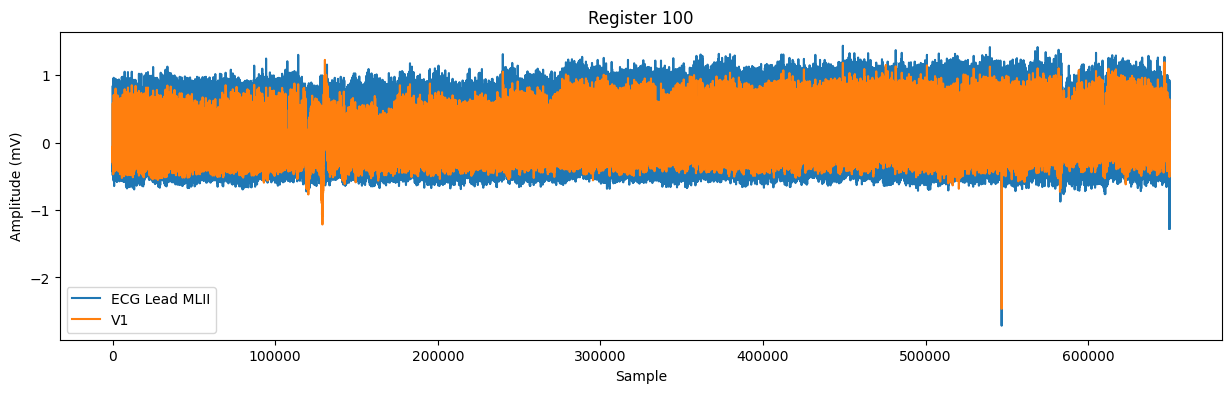

In [15]:
plt.figure(figsize=(15,4))
plt.plot(raw_data, label=['ECG Lead MLII','V1'])
plt.title('Register 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

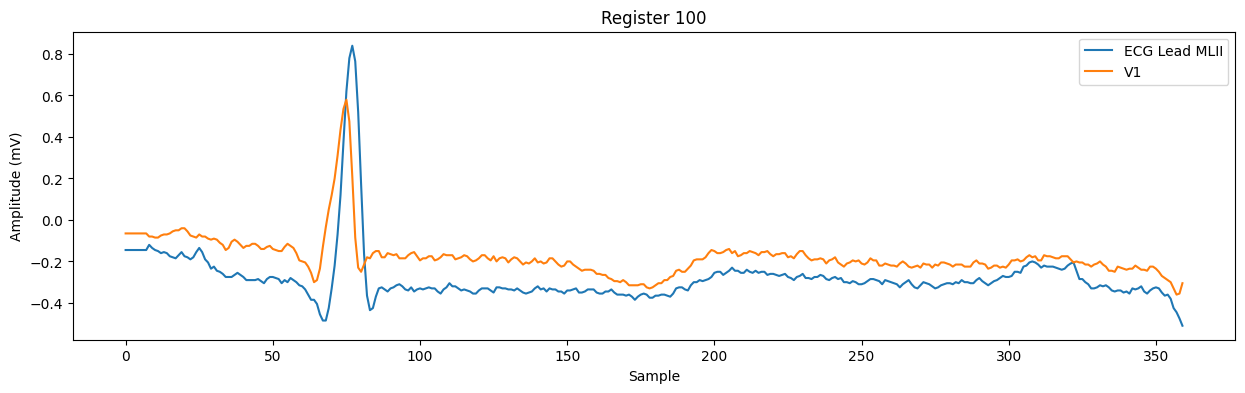

In [16]:
plt.figure(figsize=(15,4))
plt.plot(raw_data[0:360,:], label=['ECG Lead MLII','V1'])
plt.title('Register 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

In [17]:
raw_data_normalizer=normalizer(raw_data)

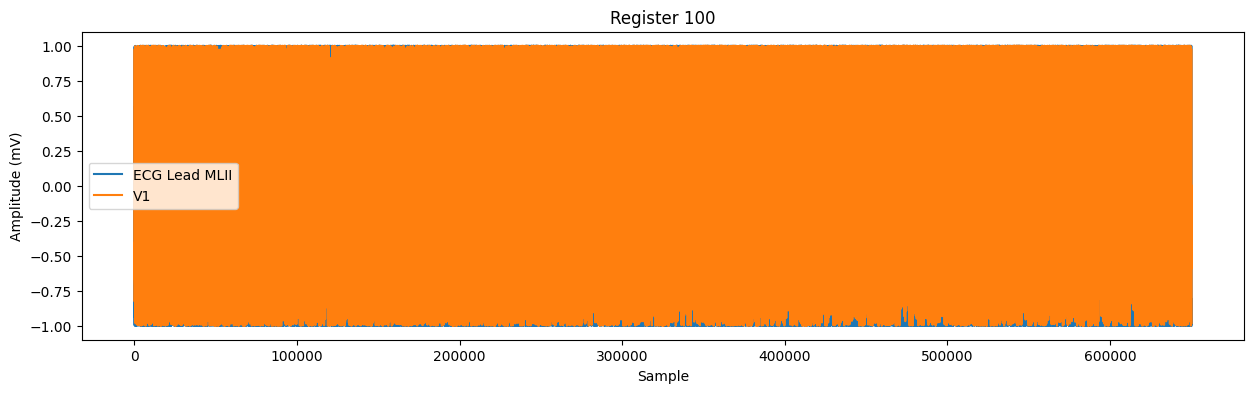

In [18]:
plt.figure(figsize=(15,4))
plt.plot(raw_data_normalizer, label=['ECG Lead MLII','V1'])
plt.title('Register 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

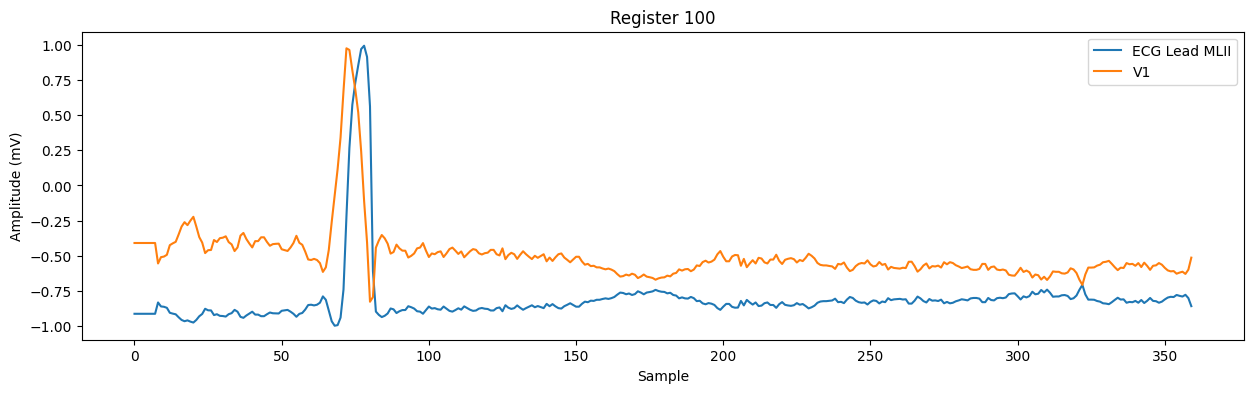

In [19]:
plt.figure(figsize=(15,4))
plt.plot(raw_data_normalizer[0:360,:], label=['ECG Lead MLII','V1'])
plt.title('Register 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

In [20]:
signal=raw_data_normalizer[:,0]
signal2=raw_data_normalizer[:,1]
qrs_indices=qrs_detect(signal,fs)
qrs_indices2=qrs_detect(signal2,fs)
print(qrs_indices,len(qrs_indices))
print(qrs_indices2,len(qrs_indices2))

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[    77    370    662 ... 649484 649733 649992] 2273
[    73    366    659 ... 649480 649730 649995] 2269


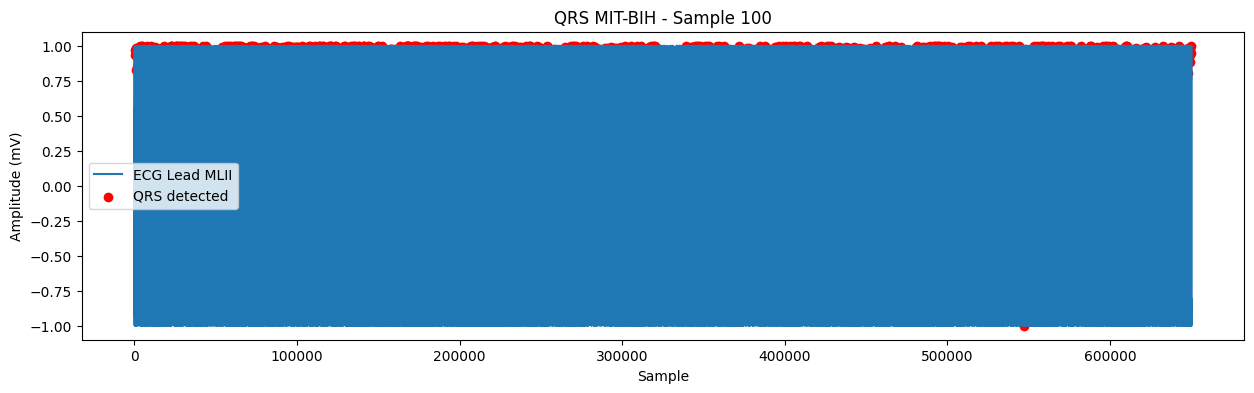

In [21]:
plt.figure(figsize=(15,4))
plt.plot(signal, label='ECG Lead MLII')
plt.scatter(qrs_indices, signal[qrs_indices], color='red', label='QRS detected')
plt.title('QRS MIT-BIH - Sample 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

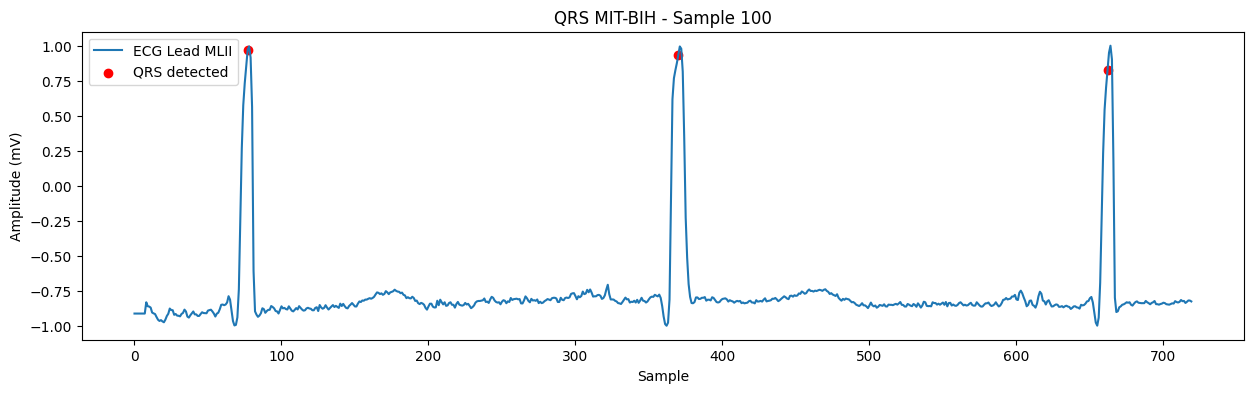

In [22]:
plt.figure(figsize=(15,4))
plt.plot(signal[0:720], label='ECG Lead MLII')
plt.scatter(qrs_indices[0:3], signal[qrs_indices[0:3]], color='red', label='QRS detected')
plt.title('QRS MIT-BIH - Sample 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

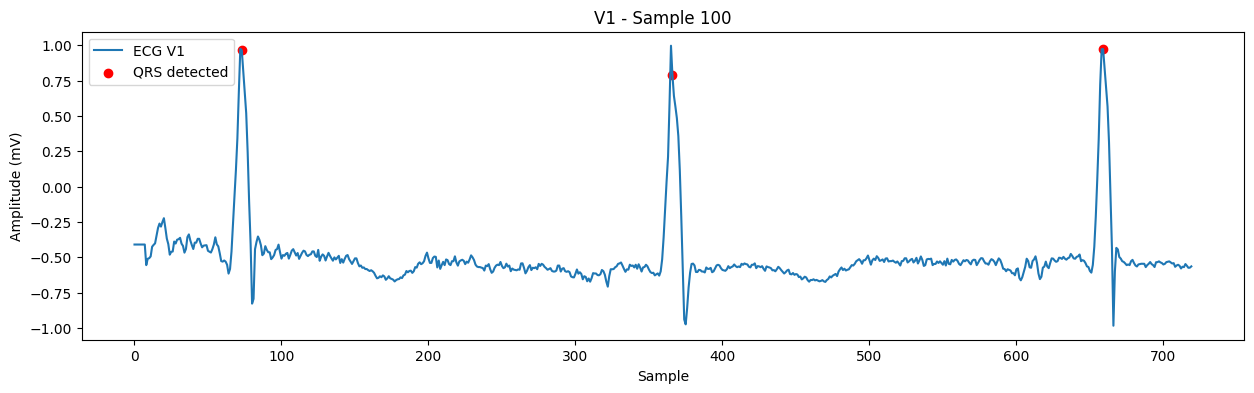

In [23]:
plt.figure(figsize=(15,4))
plt.plot(signal2[0:720], label='ECG V1')
plt.scatter(qrs_indices2[0:3], signal2[qrs_indices2[0:3]], color='red', label='QRS detected')
plt.title('V1 - Sample 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

In [24]:
segments=segment(signal,qrs_indices,fs)
print(len(segments))

2272


In [25]:
segments2=segment(signal2,qrs_indices2,fs)
print(len(segments2))

2268


[  24 1713  261 2189 1224]


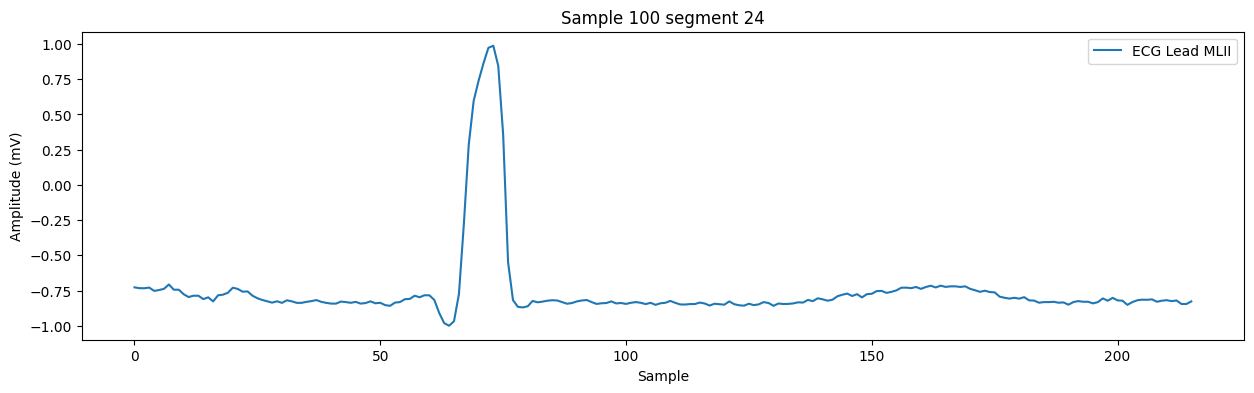

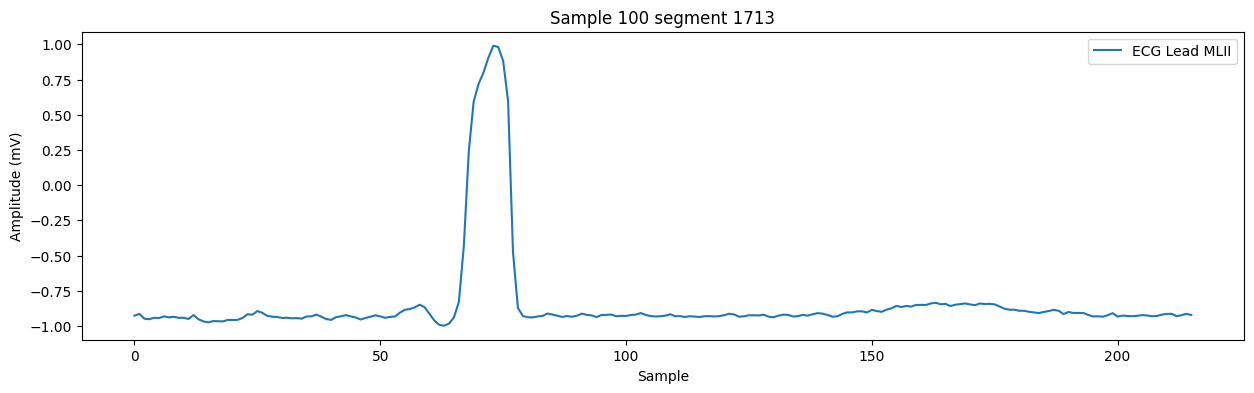

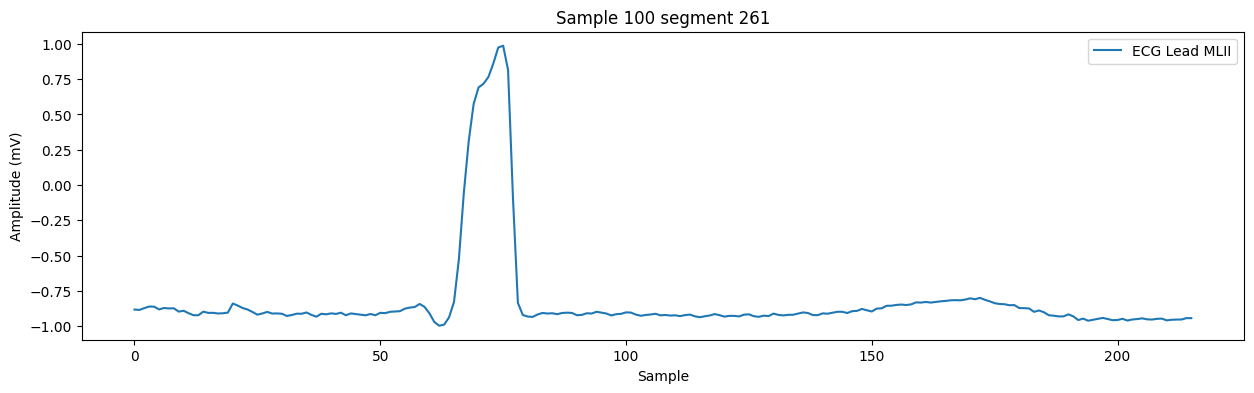

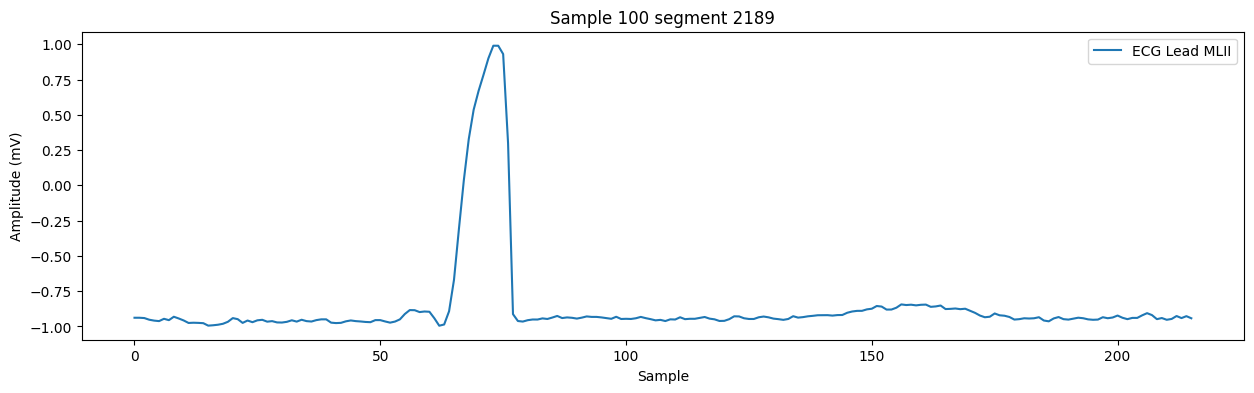

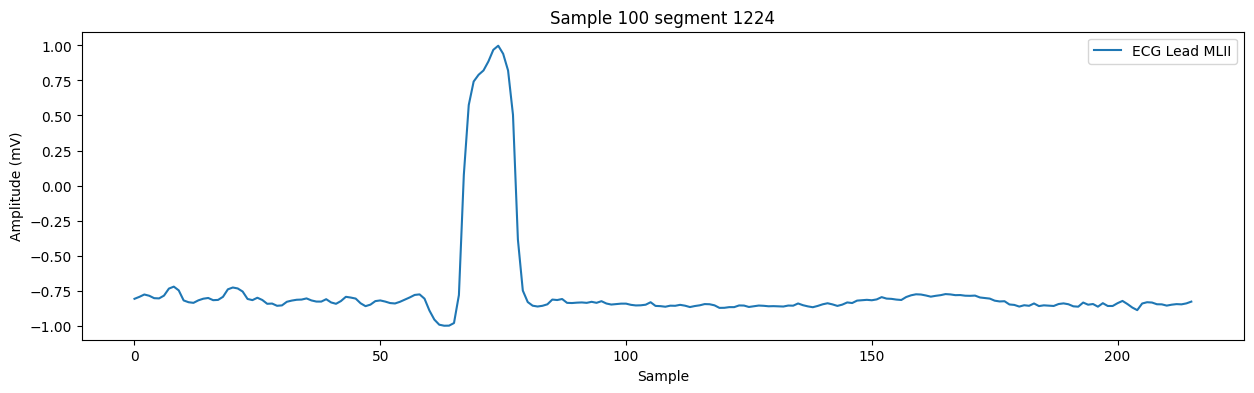

In [26]:
index=np.random.randint(0,len(segments),5)
print(index)
for i in index:
  plt.figure(figsize=(15,4))
  plt.plot(segments[i], label='ECG Lead MLII')
  plt.title('Sample 100 segment {0}'.format(i))
  plt.xlabel('Sample')
  plt.ylabel('Amplitude (mV)')
  plt.legend()
  plt.show()

[ 348  632 2157 2117  643]


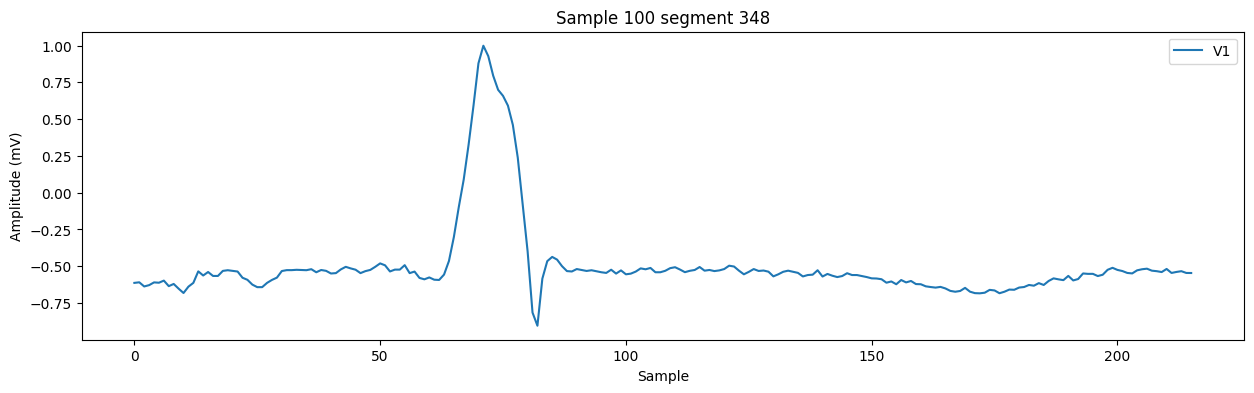

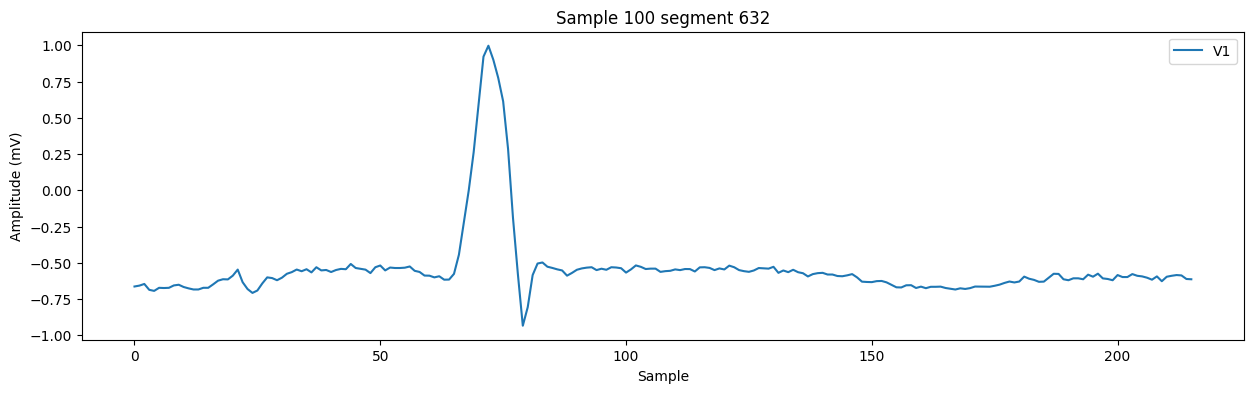

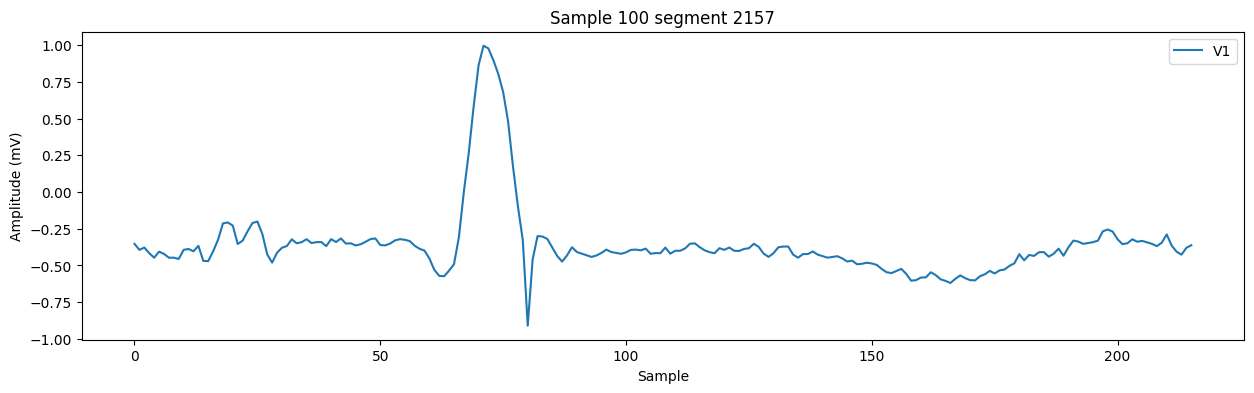

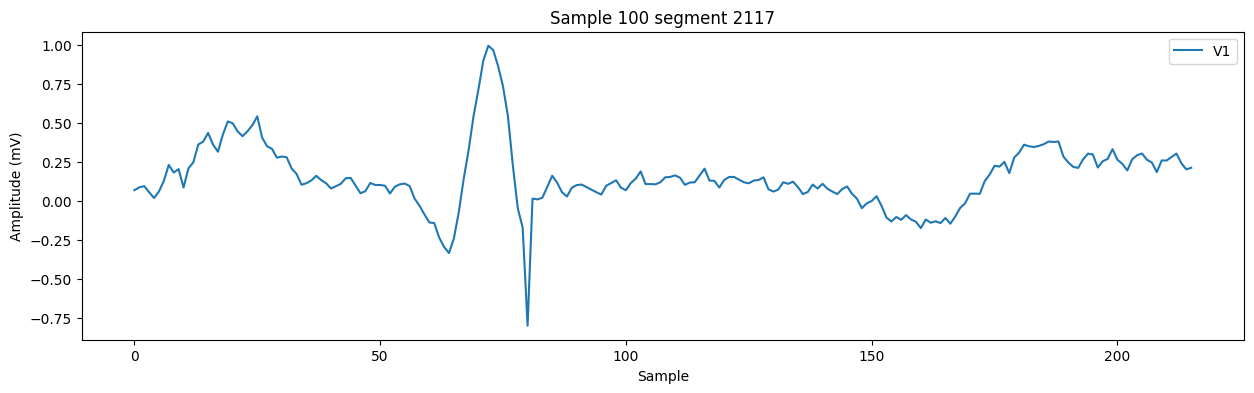

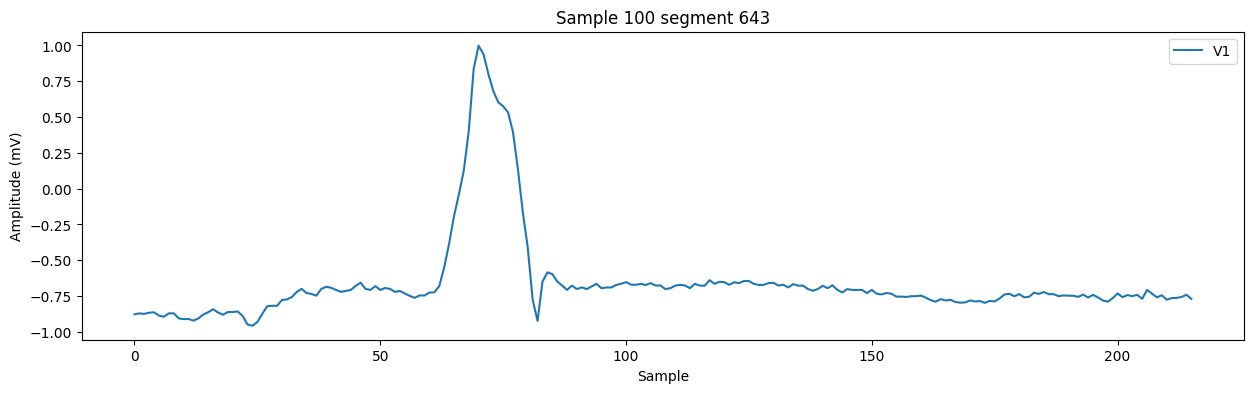

In [27]:
index=np.random.randint(0,len(segments2),5)
print(index)
for i in index:
  plt.figure(figsize=(15,4))
  plt.plot(segments2[i], label='V1')
  plt.title('Sample 100 segment {0}'.format(i))
  plt.xlabel('Sample')
  plt.ylabel('Amplitude (mV)')
  plt.legend()
  plt.show()

[1225 1566  767 1096  356]


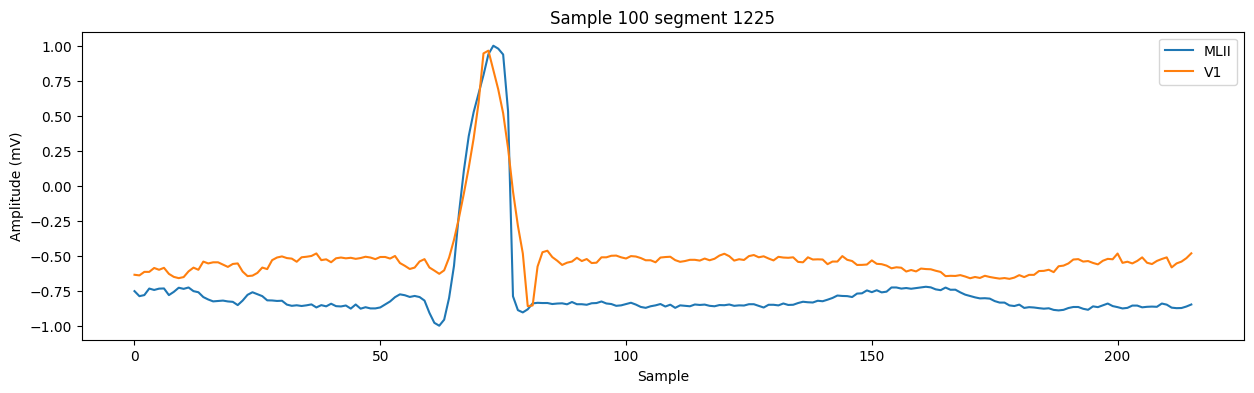

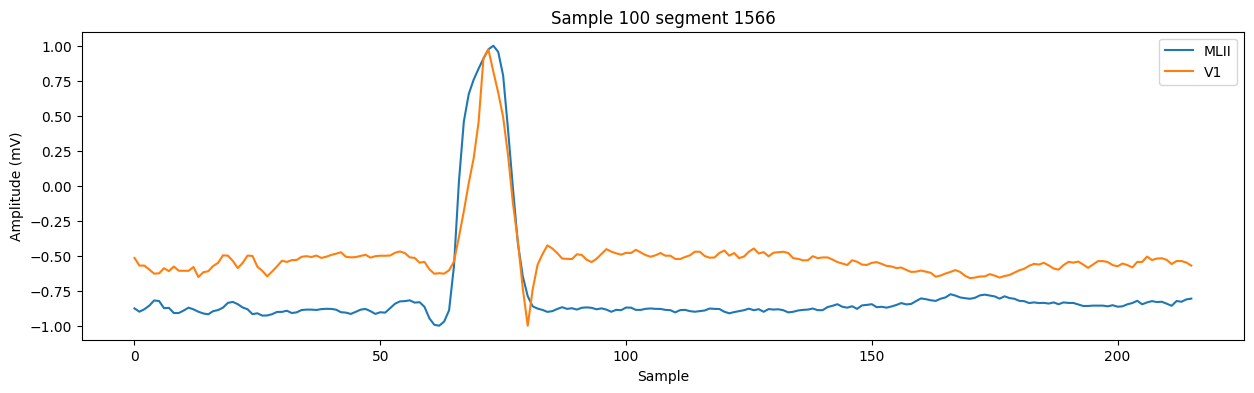

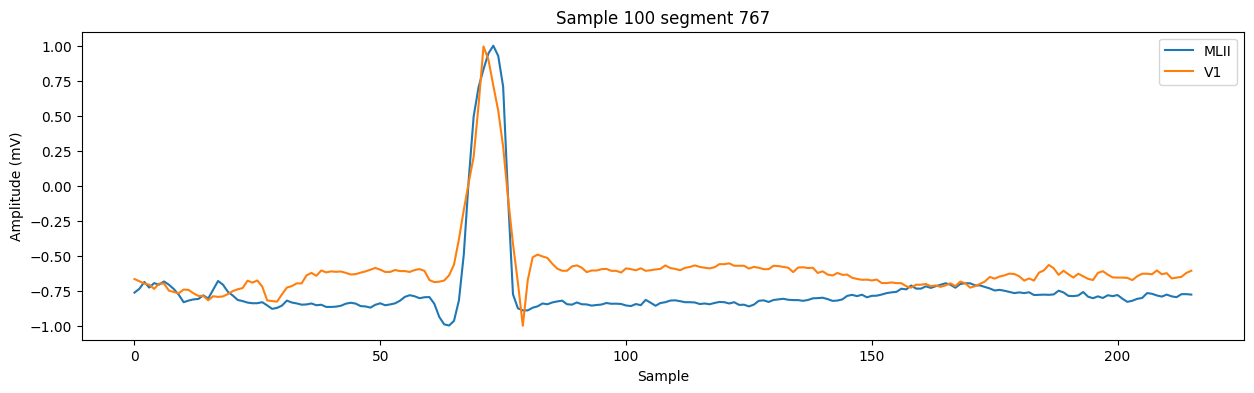

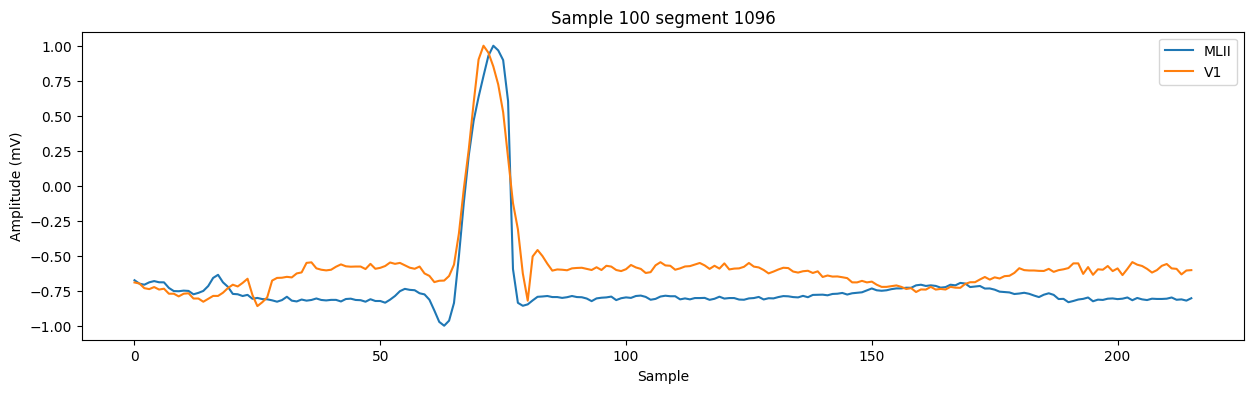

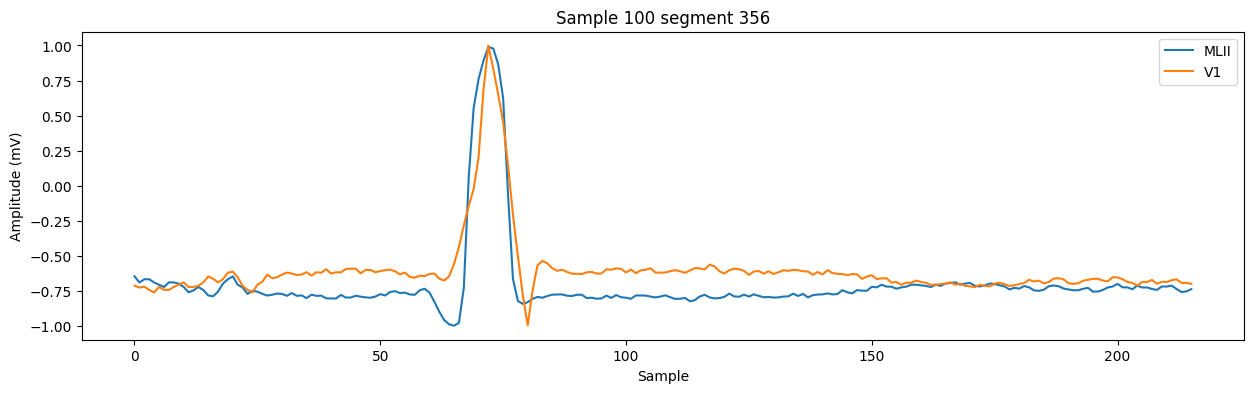

In [28]:
index=np.random.randint(0,len(segments2),5)
print(index)
for i in index:
  plt.figure(figsize=(15,4))
  plt.plot(segments[i], label='MLII')
  plt.plot(segments2[i], label='V1')
  plt.title('Sample 100 segment {0}'.format(i))
  plt.xlabel('Sample')
  plt.ylabel('Amplitude (mV)')
  plt.legend()
  plt.show()

In [29]:
segments=np.array(segments)
print(segments.shape)

(2272, 216)


In [30]:
segments2=np.array(segments2)
print(segments2.shape)

(2268, 216)


In [31]:
# Parameters
lowcut = 0.5      # Hz (low band)
highcut = 40.0    # Hz (hight band)
notch_freq = 60   # Hz (50 Hz from Europe)
Q = 30            # quality factor notch

filtered_segments = filter_data(segments, fs, lowcut, highcut, notch_freq, Q)
filtered_segments_median = filter_data(segments, fs, lowcut, highcut, notch_freq, Q,ismedian=True)
filtered_segments_moving = filter_data(segments, fs, lowcut, highcut, notch_freq, Q,ismedian=True,ismoving=True)
print(filtered_segments.shape)

(2272, 216)


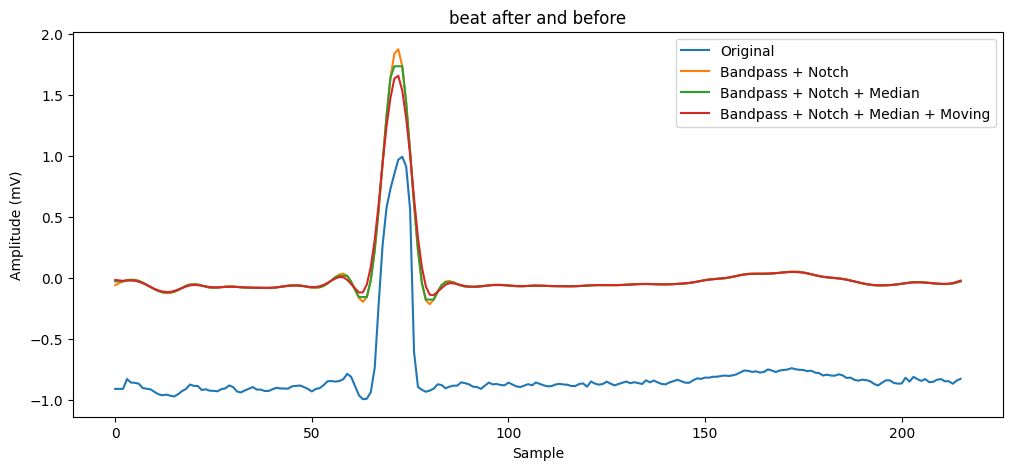

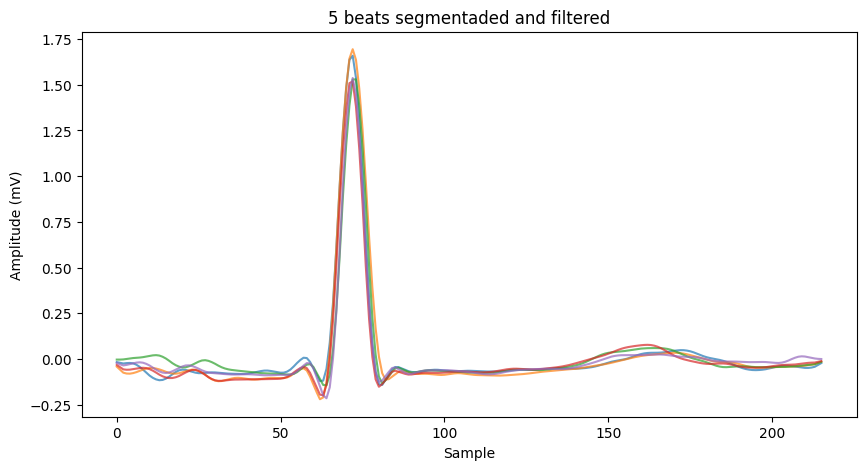

In [32]:
# Show first beat before and later
idx = 0  # first beat
plt.figure(figsize=(12,5))
plt.plot(segments[idx], label='Original')
plt.plot(filtered_segments[idx], label='Bandpass + Notch')
plt.plot(filtered_segments_median[idx], label='Bandpass + Notch + Median')
plt.plot(filtered_segments_moving[idx], label='Bandpass + Notch + Median + Moving')
plt.title('beat after and before')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()


# Show five heartbeats
plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(filtered_segments_moving[i], alpha=0.7)
plt.title('5 beats segmentaded and filtered')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

In [33]:
# Parameters
lowcut = 0.5      # Hz (low band)
highcut = 40.0    # Hz (hight band)
notch_freq = 60   # Hz (50 Hz from Europe)
Q = 30            # quality factor notch

filtered_segments2 = filter_data(segments2, fs, lowcut, highcut, notch_freq, Q)
filtered_segments_median2 = filter_data(segments2, fs, lowcut, highcut, notch_freq, Q,ismedian=True)
filtered_segments_moving2 = filter_data(segments2, fs, lowcut, highcut, notch_freq, Q,ismedian=True,ismoving=True)
print(filtered_segments.shape)

(2272, 216)


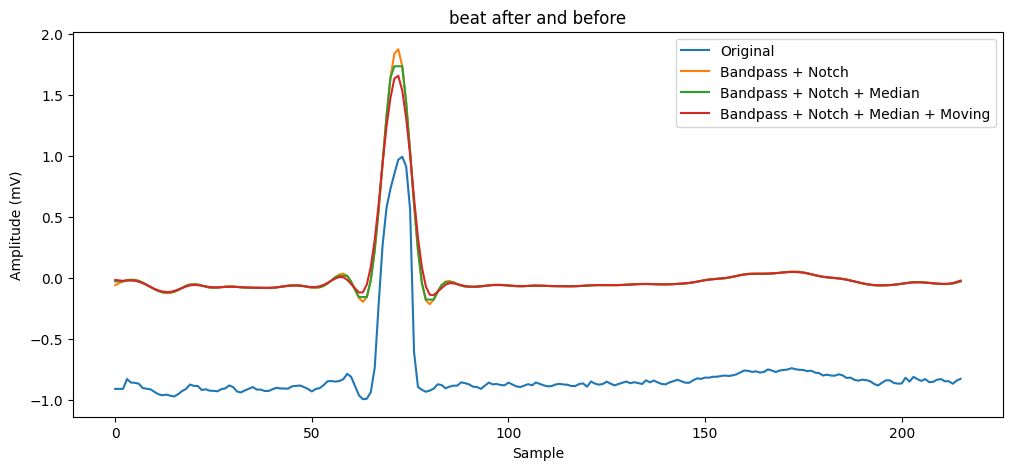

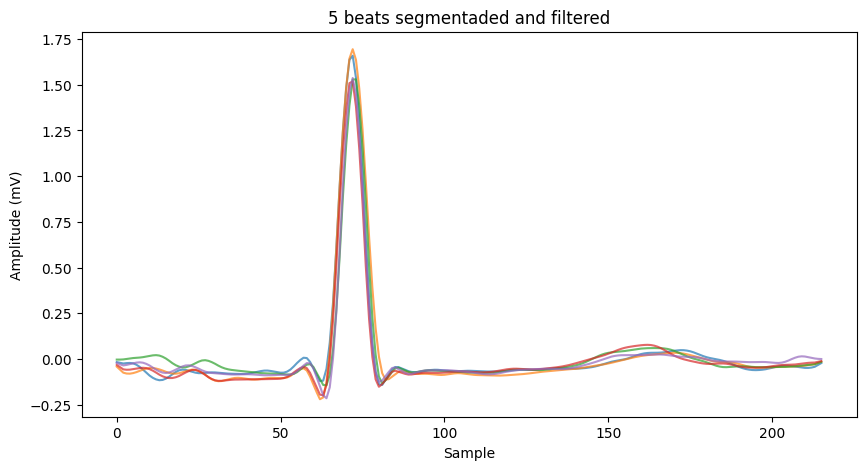

In [34]:
# Show first beat before and later
idx = 0  # first beat
plt.figure(figsize=(12,5))
plt.plot(segments[idx], label='Original')
plt.plot(filtered_segments[idx], label='Bandpass + Notch')
plt.plot(filtered_segments_median[idx], label='Bandpass + Notch + Median')
plt.plot(filtered_segments_moving[idx], label='Bandpass + Notch + Median + Moving')
plt.title('beat after and before')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()


# Show five heartbeats
plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(filtered_segments_moving[i], alpha=0.7)
plt.title('5 beats segmentaded and filtered')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

In [35]:
os.makedirs("processed_signals", exist_ok=True)
print("Carpeta creada")

Carpeta creada


In [36]:
import numpy as np
np.save("processed_signals/segments_MLII.npy", filtered_segments_moving)
np.save("processed_signals/segments_V1.npy", filtered_segments_moving2)

print("Señales guardadas")

Señales guardadas


In [37]:
#Clustering necesita una tabla, no señales en forma de onda.
X_MLII = filtered_segments_moving.reshape(
    filtered_segments_moving.shape[0],
    -1
)

np.save("processed_signals/X_MLII_flat.npy", X_MLII)

print("Datos listos para clustering guardados")

Datos listos para clustering guardados
